## Gene Embedding Analysis Tutorial

In this notebook, we will explore gene embeddings as an approach for de novo gene program discovery. The genes identified in these programs may also serve as potential candidates for perturbation studies.
To illustrate this, we will construct a new AnnData object derived from the gene embeddings. In this object, each obs_name corresponds to a gene at a specific timepoint, and the matrix X stores the embedding values for that gene.

Load the libraries

In [1]:
import scanpy as sc
import matplotlib as mpl
import numpy as np
import pandas as pd
import anndata as ad
import gseapy as gp
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

Here, we load the .h5ad object that contains both the cell and gene embeddings generated by PerturbGen. The cell embedding is computed as the average of the embeddings of all genes within that cell.

In [2]:
adata = sc.read('/lustre/scratch126/cellgen/lotfollahi/dv8/trace/T_perturb/cytomeister/plt/res/lps/embedding_100mMedE0e7_int_2k_all_tps_lps/embeddings/20250715-12:10_inference_embs_t[1, 2, 3]_scmaskgit_mcosine.h5ad')

For each timepoint, the model provides gene embeddings, which are stored in varm. In addition, the cell embeddings are available under cls_embeddings.

In [3]:
adata

AnnData object with n_obs × n_vars = 69433 × 2000
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'
    var: 'token_id'
    obsm: 'cls_embeddings'
    varm: '10h_LPS', '6h_LPS', '90m_LPS'

Optionally, We renamed the cell types for consitency. Also, Cell embeddings can be used for neighbor calculations and UMAP visualization.

In [4]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata.obs['cell_type_harmonized'] = adata.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata.obs['cell_type_harmonized'].cat.categories}
)

/software/cellgen/team361/am74/envs/scvi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


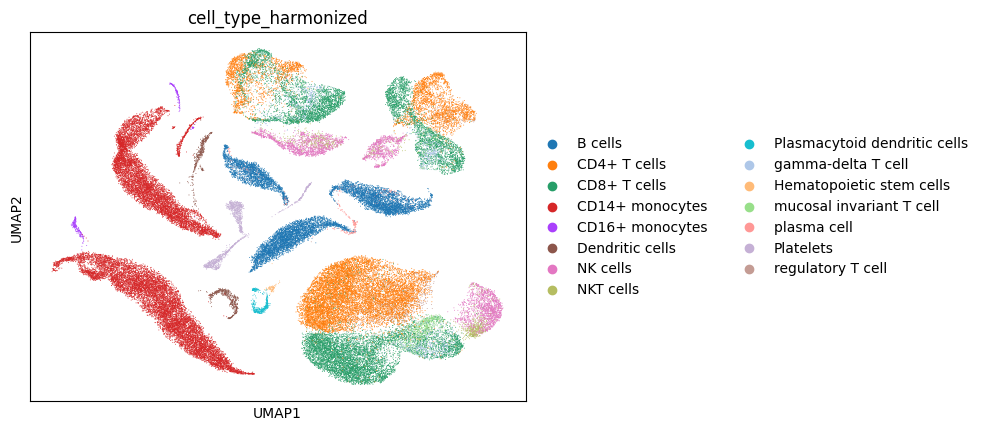

In [5]:
sc.pp.neighbors(adata,use_rep='cls_embeddings')
sc.tl.umap(adata)
sc.pl.umap(adata,color='cell_type_harmonized')

At this step, we use the original data to get a mapping dictionary so we can translate the Ensembl IDs in the gene embedding object into readable gene symbols.

In [7]:
adata_full = sc.read('/nfs/team361/am74/Cytomeister/Evaluation_datasets/LPS/full_lps.h5ad')

We normalize and log-transform the original AnnData object to generate a raw UMAP visualization. This step is optional and serves mainly to provide a comparison with PerturbGen cell-embedding UMAP.

In [9]:
sc.pp.normalize_total(adata_full)
sc.pp.log1p(adata_full)

In [10]:
sc.pp.neighbors(adata_full)
sc.tl.umap(adata_full)

/software/cellgen/team361/am74/envs/scvi/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 13826 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [11]:
mapping = {
    'B cell': 'B cells',
    'CD14 monocytes': 'CD14+ monocytes',
    'CD16 monocytes': 'CD16+ monocytes',
    'CD4+ T cells': 'CD4+ T cells',
    'CD8+ T cells': 'CD8+ T cells',
    'Dendritic cells': 'Dendritic cells',
    'NK': 'NK cells',
    'NKT': 'NKT cells',
    'Plasmocytoid dendritic cell': 'Plasmacytoid dendritic cells',
    'hematopoietic stem cell': 'Hematopoietic stem cells',
    'platelet': 'Platelets'
}

adata_full.obs['cell_type_harmonized'] = adata_full.obs['cell_type_harmonized'].cat.rename_categories(
    {cat: mapping.get(cat, cat) for cat in adata_full.obs['cell_type_harmonized'].cat.categories}
)


In [12]:
sc.set_figure_params(dpi_save=600)

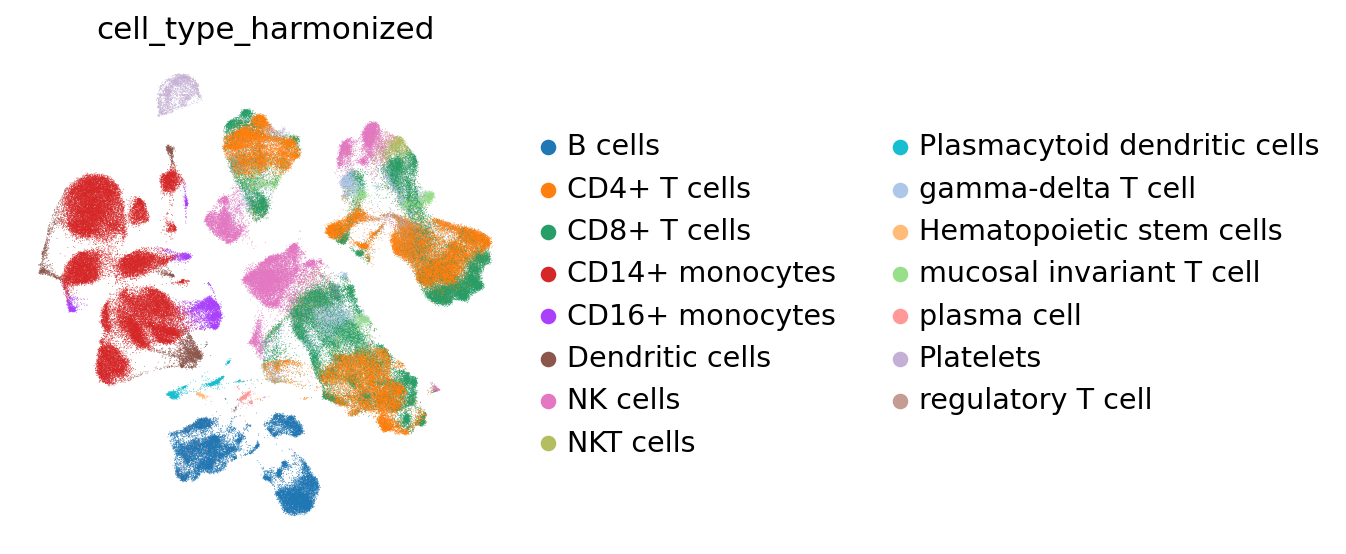

In [13]:

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42, 
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

sc.pl.umap(
    adata_full,
    color='cell_type_harmonized',
    frameon=False,
    save='_umapcelltype.png'  
)


Here we take the Ensembl IDs in the gene embedding object and match them to their gene symbols from the original data.

In [14]:
adata.var['gene_symbol'] = adata.var.index.map(adata_full.var['gene_symbol-0'])

Now we build a new object for the gene embeddings. Here, every gene is treated like a cell, but instead of expression values we use its 768-dimensional embedding vector. With this object, you can easily run UMAP and perform clustering.

In [15]:
gene_symbols = adata.var['gene_symbol'].values
timepoints = list(adata.varm.keys())

all_embeddings = []
obs_names = []
obs_timepoints = []
obs_genes = []

for tp in timepoints:
    embedding = adata.varm[tp]  
    all_embeddings.append(embedding)
    
    obs_names.extend([f"{g}_{tp}" for g in gene_symbols])
    obs_genes.extend(gene_symbols)
    obs_timepoints.extend([tp] * len(gene_symbols))

X = np.vstack(all_embeddings)

obs = pd.DataFrame({
    "gene_symbol": obs_genes,
    "timepoint": obs_timepoints
}, index=obs_names)

new_adata = ad.AnnData(X=X, obs=obs)

2.Remove Genes with all 0 values

In [17]:
zero_mask = (new_adata.X == 0).all(axis=1)

num_all_zero = zero_mask.sum()

print(f"Number of gene-timepoint vectors with all-zero values: {num_all_zero}")


Number of gene-timepoint vectors with all-zero values: 37


In [18]:
new_adata = new_adata[~zero_mask].copy()

Now we calculate the neighbors and create a UMAP plot for the gene embeddings object.

In [19]:
sc.pp.neighbors(new_adata)
sc.tl.umap(new_adata)

/software/cellgen/team361/am74/envs/scvi/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 768 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


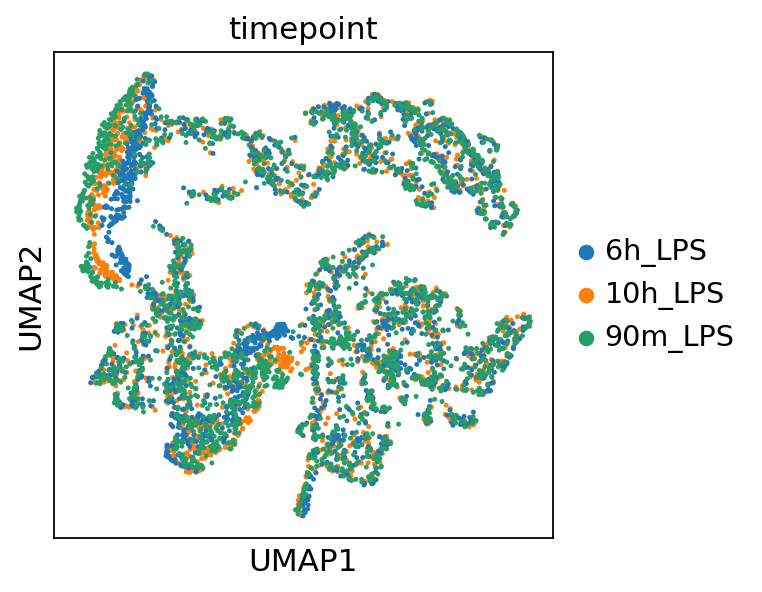

In [20]:
sc.pl.umap(new_adata,color='timepoint')

To identify gene programs, we perform Leiden clustering on the gene embeddings. Each resulting cluster of genes is considered a distinct gene program.

In [21]:
sc.tl.leiden(new_adata,resolution=1,key_added='r1')

/tmp/ipykernel_4059029/1903070418.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(new_adata,resolution=1,key_added='r1')


For annotating gene programs, we recommend using predefined gene sets as guidance.


In [23]:
results = {}

for cluster in new_adata.obs['r1'].unique():
    cluster_genes = new_adata.obs.loc[new_adata.obs['r1'] == cluster, 'gene_symbol'].tolist()
    
    enr = gp.enrichr(
        gene_list=cluster_genes,
        gene_sets= ['GO_Biological_Process_2025','Reactome_Pathways_2024'],
        
        organism='Human',              
        outdir=None,                  
        cutoff=0.5                     
    )
    
    results[cluster] = enr.results.sort_values('Adjusted P-value').head(5)

As an example, we annotate cluster 6 as cytokine signaling, since it contains many interleukins and chemokines. You can also calculate the z-score expression of any gene program of interest within the cell space.

In [28]:
adata_full.var_names = adata_full.var['gene_ids-0']

In [29]:
genes_cluster_6 = list(new_adata[new_adata.obs['r1']=='6'].obs['gene_symbol'])

genes_present = [g for g in genes_cluster_6 if g in adata_full.var_names]

sc.tl.score_genes(adata_full, gene_list=genes_present, score_name='Cytokine Signaling')

In [30]:
cluster_map = {
    '6': 'Cytokine Signaling',
}

new_adata.obs['MoA'] = new_adata.obs['r1'].map(cluster_map).fillna('Others')

We plot the UMAP and highlight the cluster containing the genes of interest.

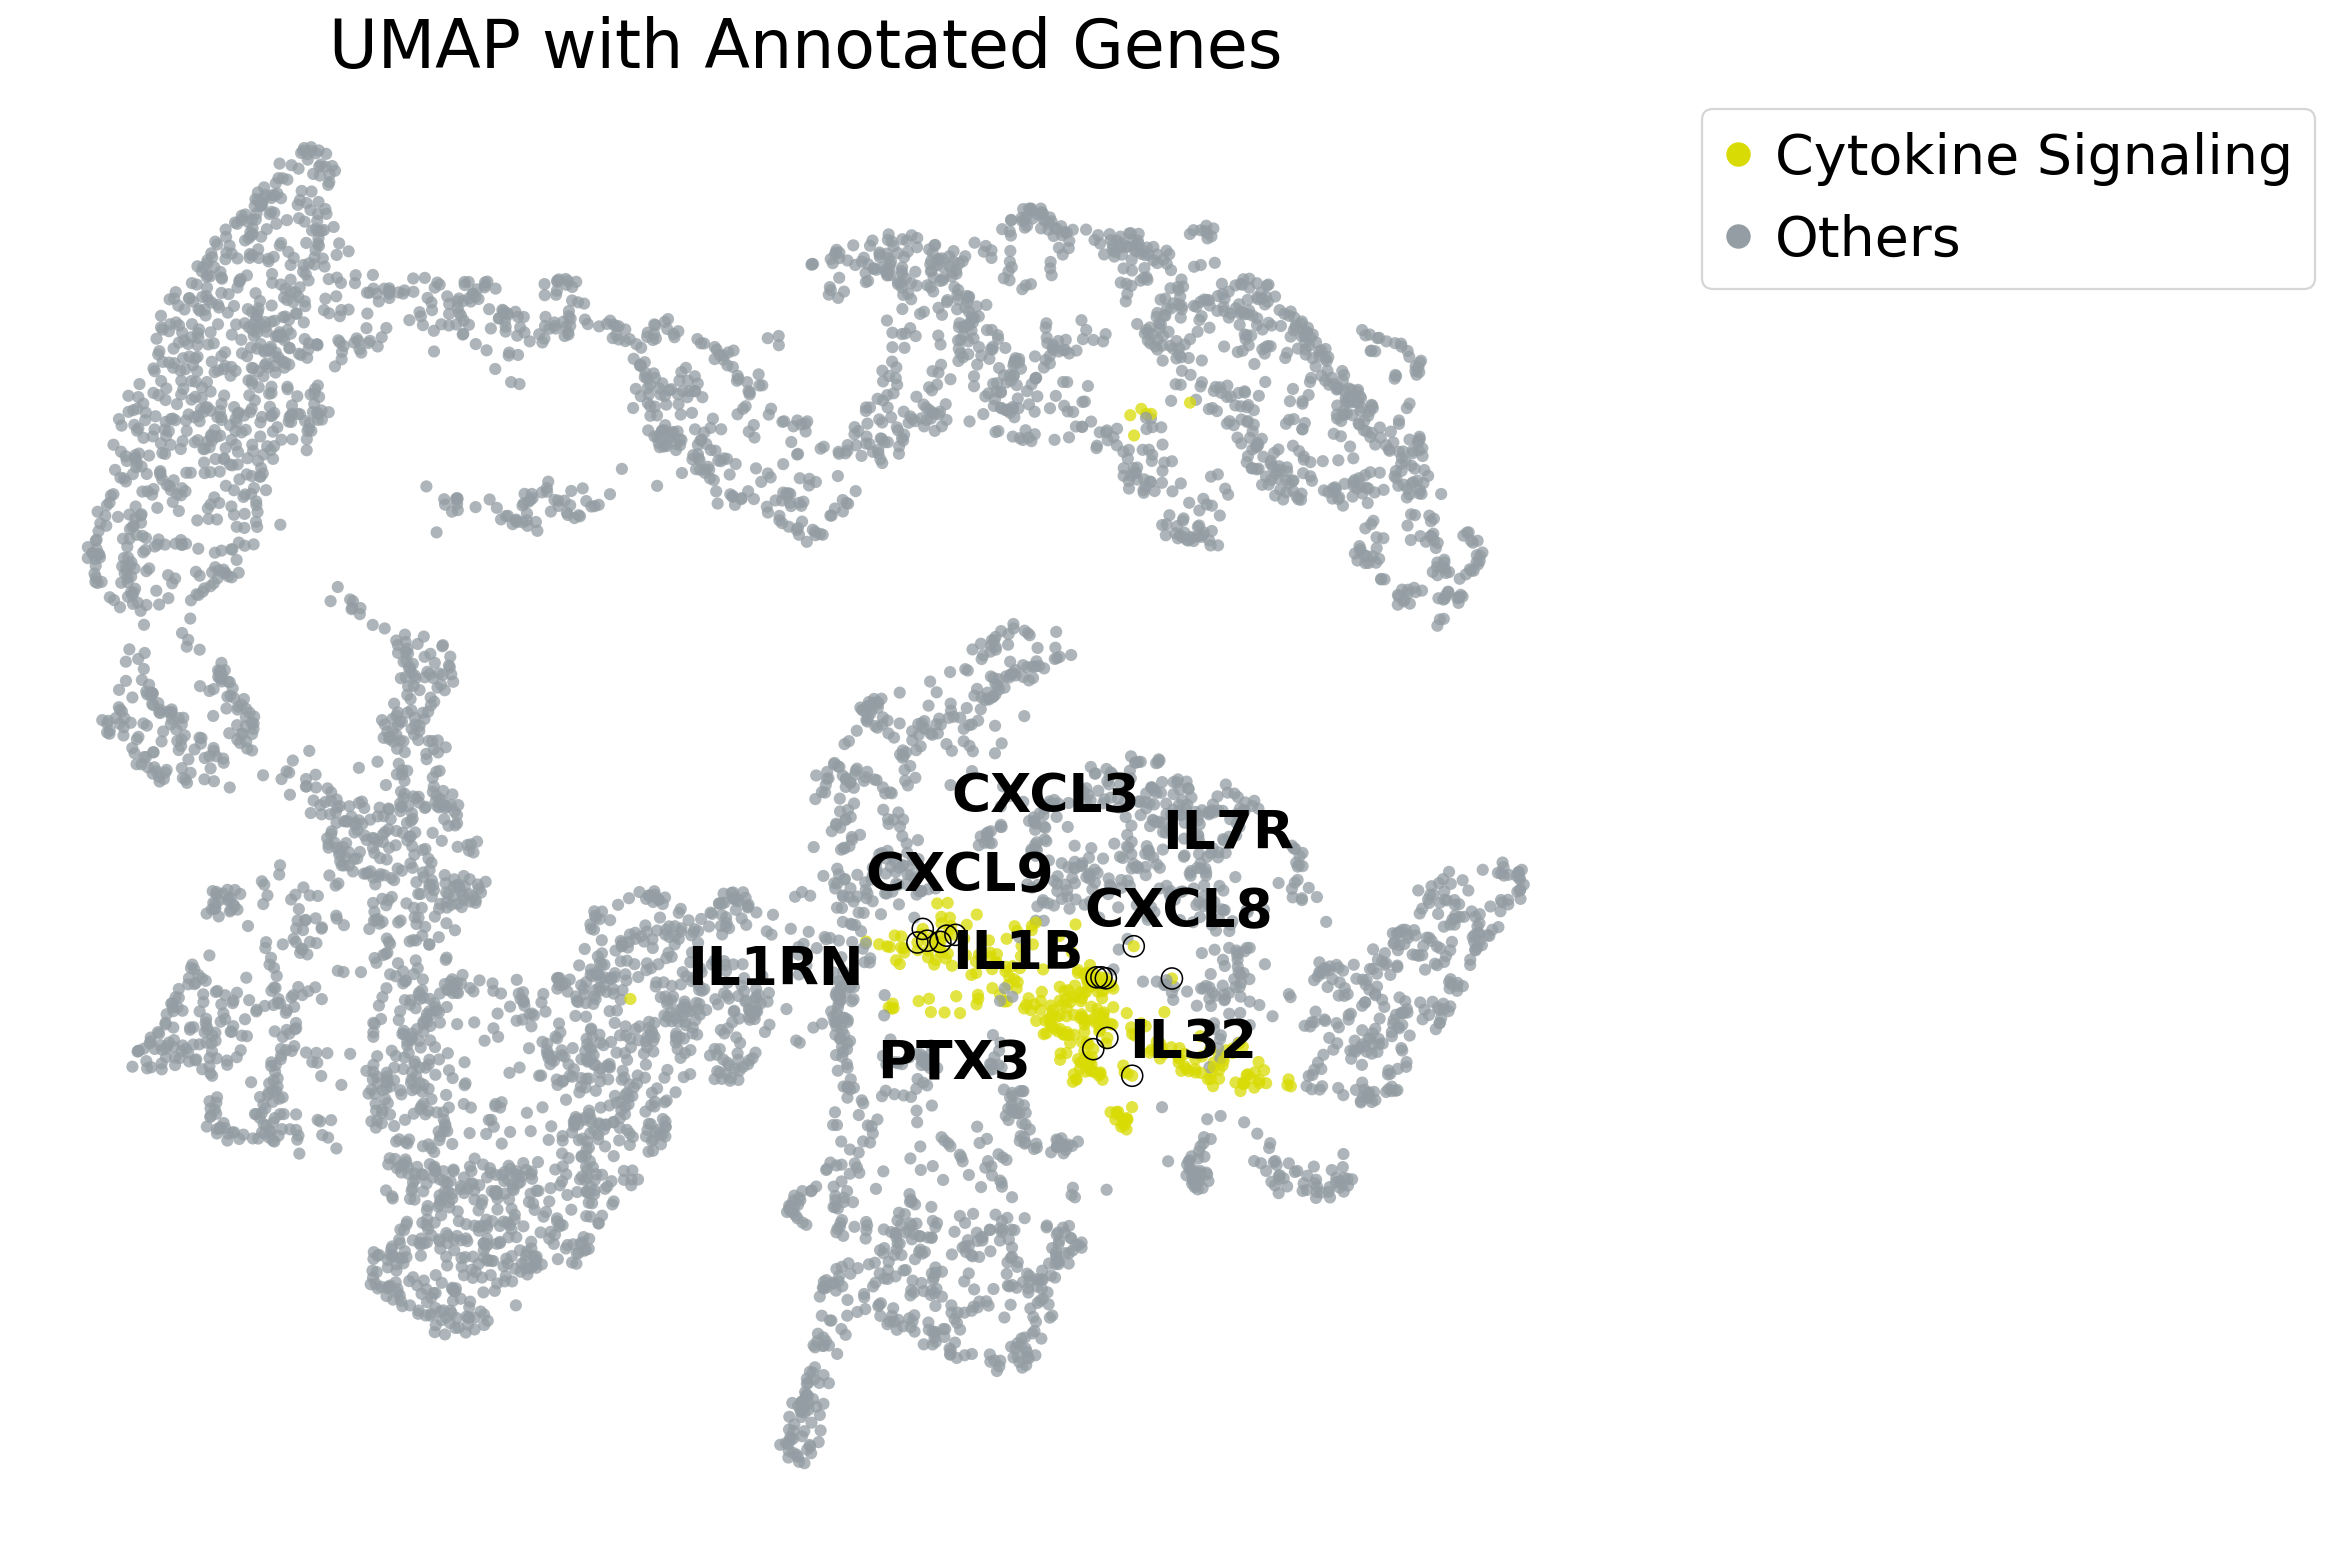

In [33]:
highlight_dict = {
    'Cytokine Signaling': ["IL1RN", "IL1B", "PTX3", "IL32", "IL7R","CXCL8","CXCL3","CXCL9"],
}
custom_colors = {
    'Cytokine Signaling': '#d9db05',
    'Others': '#939da3',
}


umap_df = pd.DataFrame(new_adata.obsm['X_umap'], columns=['UMAP1', 'UMAP2'])
umap_df['MoA']  = new_adata.obs['MoA'].astype(str).values          
umap_df['gene'] = new_adata.obs['gene_symbol'].astype(str).values  

present = sorted(umap_df['MoA'].unique())
palette = {k: custom_colors.get(k, '#939da3') for k in present}

plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=umap_df, x='UMAP1', y='UMAP2', hue='MoA',
    palette=palette, linewidth=0, alpha=0.75, s=30
)
plt.title('UMAP with Annotated Genes', fontsize=30)
plt.xlabel('UMAP1', fontsize=24); plt.ylabel('UMAP2', fontsize=24)
plt.axis('off'); plt.grid(False)

texts = []
for moa, genes in highlight_dict.items():
    for gene in genes:
        mask = (umap_df['gene'].str.upper() == gene.upper()) & (umap_df['MoA'] == moa)
        if not mask.any():
            mask = (umap_df['gene'].str.upper() == gene.upper())

        if mask.any():
            plt.scatter(
                umap_df.loc[mask, 'UMAP1'],
                umap_df.loc[mask, 'UMAP2'],
                s=90, linewidths=0.7, edgecolors='k', facecolors='none', zorder=5
            )

            x_med = umap_df.loc[mask, 'UMAP1'].median()
            y_med = umap_df.loc[mask, 'UMAP2'].median()
            jitter_x = x_med - 1.0 if gene == "IL1RN" else x_med + np.random.uniform(-0.5, 0.5)
            jitter_y = y_med + np.random.uniform(-0.5, 0.5)

            texts.append(
                plt.text(jitter_x, jitter_y, gene,
                         fontsize=24, fontweight='bold', ha='center', va='center', zorder=6)
            )

adjust_text(
    texts,
    expand_points=(15, 15),
    expand_text=(10, 10),
    force_points=5.0,
    force_text=5.0,
    pad=10.0,
    only_move={'points': 'xy', 'text': 'xy'},
    autoalign='xy',
    lim=1500
)

handles = [plt.Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette[k], markersize=12) for k in present]
plt.legend(handles=handles, labels=present, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=25)

plt.tight_layout()
plt.savefig('umap_highlight_gene_symbol.png', dpi=600)
plt.show()


Optionally, you may visualize the z-score expression of a gene program of interest, stratified by cell type or another relevant variable.

/tmp/ipykernel_4059029/4172334640.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('cell_type_harmonized')['Cytokine Signaling']
/tmp/ipykernel_4059029/4172334640.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


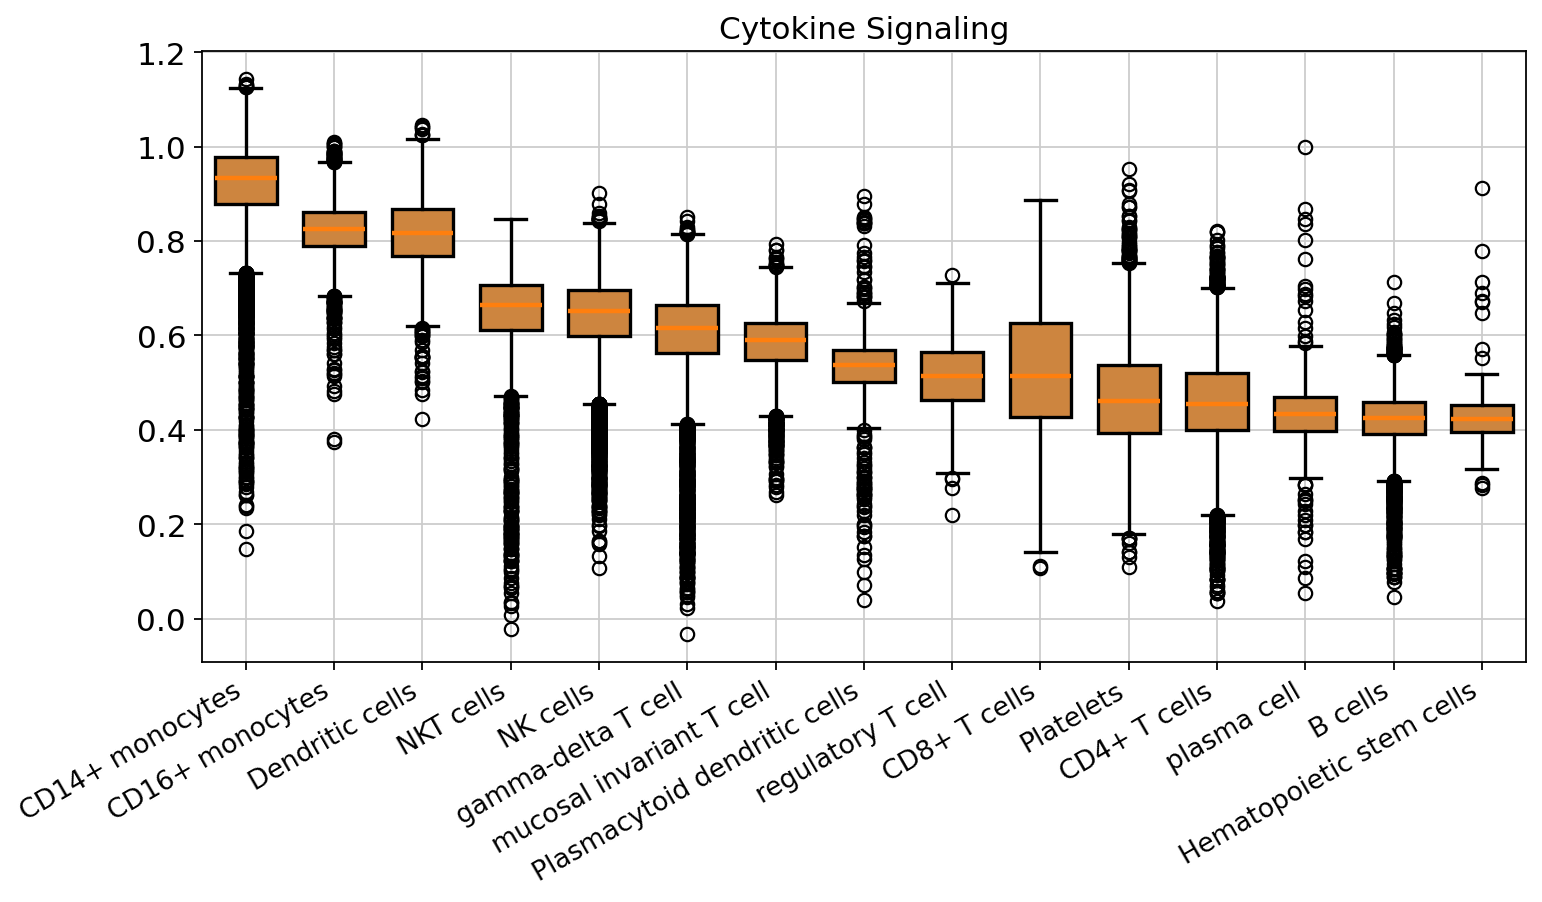

In [34]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})


df = adata_full.obs[['cell_type_harmonized', 'Cytokine Signaling']].dropna()

ordered_cell_types = (
    df.groupby('cell_type_harmonized')['Cytokine Signaling']
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)

data = [df.loc[df['cell_type_harmonized'] == ct, 'Cytokine Signaling'].values
        for ct in ordered_cell_types]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(
    data,
    patch_artist=True,  
    labels=ordered_cell_types,
    widths=0.7,
    medianprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    boxprops=dict(linewidth=1.5)
)

for box in bp['boxes']:
    box.set_facecolor('peru')

ax.set_title('Cytokine Signaling')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
fig.tight_layout()
fig.savefig("./cytokine_signaling_boxplot.png", dpi=600, bbox_inches='tight', format='pdf')
plt.show()


We subset the data to the myeloid lineage, as the gene program was highly enriched in these cells. We then examined the gene program scores within the myeloid population across different timepoints.

In [35]:
myeloids = adata_full[adata_full.obs['cell_type_harmonized'].isin(['CD14+ monocytes','CD16+ monocytes','Dendritic cells'])].copy()

In [36]:
s = myeloids.obs['time_after_LPS'].astype('category')

rename_map = {
    '90m_LPS': '90m',
    '6h_LPS':  '6h',
    '10h_LPS': '10h',
    'normal':  'normal',
}
s = s.cat.rename_categories({k: v for k, v in rename_map.items() if k in s.cat.categories})

new_order = ['normal', '90m', '6h', '10h']
s = s.cat.reorder_categories(new_order, ordered=True)

myeloids.obs['time_after_LPS'] = s

palette = {
    'normal': '#d62728',
    '90m':    '#2ca02c',
    '6h':     '#1f77b4',
    '10h':    '#ff7f0e',
}
myeloids.uns['time_after_LPS_colors'] = [palette[c] for c in s.cat.categories]


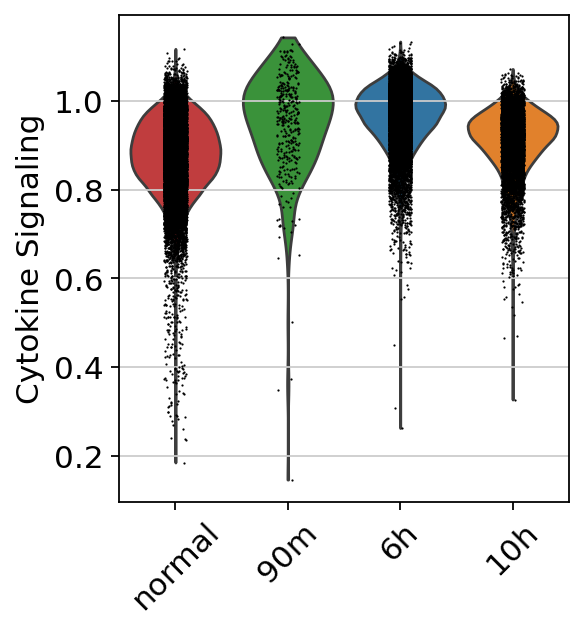

In [37]:
sc.pl.violin(myeloids,keys='Cytokine Signaling',groupby='time_after_LPS',rotation=45,save='myeloids.png')